In [53]:
import os
from dotenv import load_dotenv
from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import importlib
import turing_deinterleaving_challenge as tdc
importlib.reload(tdc)

load_dotenv()

True

In [2]:
win_length = 1024
min_emitters = 2
tdc_stare = tdc.DeinterleavingChallengeDataset(
    local_path=f"{os.getenv("TSRD_PATH")}/test_stare/",
    window_length=win_length,
    min_emitters = min_emitters
)

Processing files for windows: 100%|██████████| 250/250 [00:37<00:00,  6.70file/s]


In [3]:
pt_data, emitter_l = tdc_stare[0]
pt_data.shape, emitter_l.shape

((1024, 5), (1024,))

In [4]:
len(tdc_stare)

357371

In [5]:
 # create several identity cluster instances that are based on different eps values
cluster_algo = "hdbscan"
hdbscan_model_list = [{"cluster_selection_epsilon": eps, "copy": True} for eps in [.0, .05, .1, .5]]
identity_model_list = [
    tdc.models.model.IdentityModel(
        clusterer=cluster_algo,
        cl_params=params,
        default_label=-1
    ) for params in hdbscan_model_list
]

In [ ]:
# shorter evaluation to find optimal clustering parameters
dataset_performance = []
for i_model, model in enumerate(identity_model_list):
    print(f"Model {i_model + 1} | {len(identity_model_list)}")
    dataset_performance.append(tdc.models.evaluate.evaluate_model_on_dataset(
        model=model,
        dataloader=tdc_stare,
        return_average=False,
        n_jobs=10,
        max_eval=1000,  # limit to evaluating 1000 pulse train windows
    ))

Model 1 | 4


Evaluating model: 1000it [00:02, 430.71it/s]
Fetch results: 100%|██████████| 1000/1000 [00:59<00:00, 16.87it/s]

Model 2 | 4



Evaluating model: 1000it [00:02, 449.76it/s]
Fetch results: 100%|██████████| 1000/1000 [00:58<00:00, 17.16it/s]

Model 3 | 4



Evaluating model: 1000it [00:02, 433.35it/s]
Fetch results: 100%|██████████| 1000/1000 [01:02<00:00, 15.89it/s]

Model 4 | 4



Evaluating model: 1000it [00:02, 450.53it/s]
Fetch results: 100%|██████████| 1000/1000 [00:58<00:00, 17.16it/s]


In [ ]:
total_dataset_performance = {"Model": []}
for res, params in zip(dataset_performance, hdbscan_model_list):
    for k, v in res.items():
        if k not in total_dataset_performance:
            total_dataset_performance[k] = []
        total_dataset_performance[k].extend(v)
    total_dataset_performance["Model"].extend([f"eps={params["cluster_selection_epsilon"]:.2f}"] * len(v))
performance_pd = pd.DataFrame(total_dataset_performance)
performance_pd.head()

,Model,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Information,MCC,F1,discount
0,eps=0.00,0.731930,0.136534,0.230139,0.122267,0.202016,0.130246,0.095238,1.0
1,eps=0.00,0.592992,0.147154,0.235794,0.017718,0.209133,0.123198,0.259542,1.0
2,eps=0.00,0.446011,0.105514,0.170655,0.005465,0.142870,0.102084,0.106145,1.0
3,eps=0.00,0.558556,0.119000,0.196199,0.008772,0.171174,0.117276,0.097622,1.0
4,eps=0.00,0.784456,0.117754,0.204770,0.021920,0.189713,0.120952,0.213516,1.0


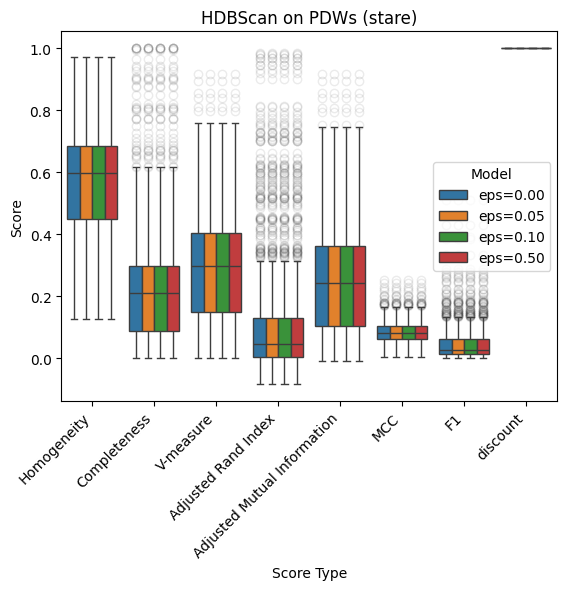

In [34]:
sns.boxplot(
    performance_pd.melt(
        id_vars=["Model"],
        value_vars=performance_pd.columns[1:].tolist(),
        var_name="Score Type",
        value_name="Score"
    ),
    x="Score Type",
    y="Score",
    hue="Model",
    palette="tab10",
    flierprops={"alpha": .1},
)
plt.xticks(rotation=45, ha="right")
plt.title("HDBScan on PDWs (stare)")
plt.show()

In [18]:
median_summary = performance_pd.melt(
        id_vars=["Model"],
        value_vars=performance_pd.columns[1:].tolist(),
        var_name="Score Type",
        value_name="Score"
).groupby(["Model", "Score Type"]).median().sort_index()
median_summary

Score
Model    Score Type                           
eps=0.00 Adjusted Mutual Information  0.242833
         Adjusted Rand Index          0.045671
         Completeness                 0.208992
         F1                           0.027027
         Homogeneity                  0.598815
         MCC                          0.079948
         V-measure                    0.295986
         discount                     1.000000
eps=0.05 Adjusted Mutual Information  0.242833
         Adjusted Rand Index          0.045671
         Completeness                 0.208992
         F1                           0.027027
         Homogeneity                  0.598815
         MCC                          0.079948
         V-measure                    0.295986
         discount                     1.000000
eps=0.10 Adjusted Mutual Information  0.242833
         Adjusted Rand Index          0.045671
         Completeness                 0.208992
         F1                           0.027027
         Homogeneity                  0.598815
         MCC                          0.079948
         V-measure                    0.295986
         discount                     1.000000
eps=0.50 Adjusted Mutual Information  0.242833
         Adjusted Rand Index          0.045671
         Completeness                 0.208992
         F1                           0.027027
         Homogeneity                  0.598815
         MCC                          0.079948
         V-measure                    0.295986
         discount                     1.000000

In [19]:
# Arbitrarily select first model and run entire dataset against it. this might take a while...
tdc_results = tdc.models.evaluate.evaluate_model_on_dataset(
    model=identity_model_list[0],
    dataloader=tdc_stare,
    return_average=False,
    n_jobs=10,
)

Evaluating model: 357371it [20:37, 288.80it/s]
Fetch results: 100%|██████████| 357371/357371 [11:47:30<00:00,  8.42it/s]  


In [21]:
stare_performance_pd = pd.DataFrame(tdc_results)
stare_performance_pd.head()

,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Information,MCC,F1,discount
0,0.731930,0.136534,0.230139,0.122267,0.202016,0.130246,0.095238,1.0
1,0.592992,0.147154,0.235794,0.017718,0.209133,0.123198,0.259542,1.0
2,0.446011,0.105514,0.170655,0.005465,0.142870,0.102084,0.106145,1.0
3,0.558556,0.119000,0.196199,0.008772,0.171174,0.117276,0.097622,1.0
4,0.784456,0.117754,0.204770,0.021920,0.189713,0.120952,0.213516,1.0


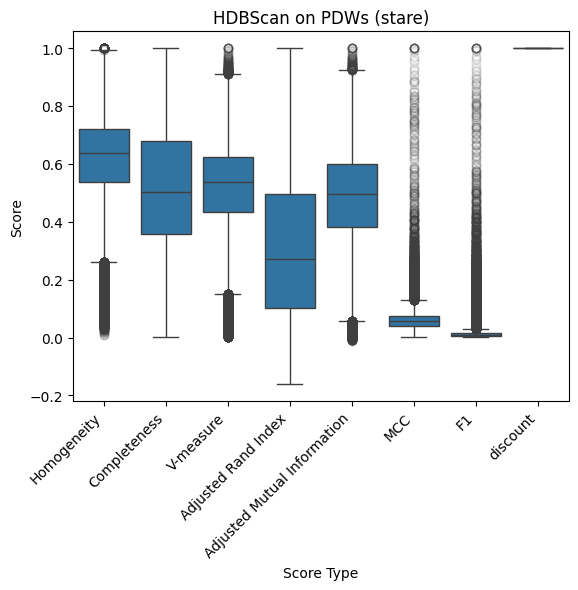

In [25]:
sns.boxplot(
    stare_performance_pd.melt(
        value_vars=stare_performance_pd.columns.tolist(),
        var_name="Score Type",
        value_name="Score"
    ),
    x="Score Type",
    y="Score",
    color="tab:blue",
    flierprops={"alpha": .1},
)
plt.xticks(rotation=45, ha="right")
plt.title("HDBScan on PDWs (stare)")
plt.show()

In [28]:
median_stare_summary = stare_performance_pd.melt(
        value_vars=stare_performance_pd.columns.tolist(),
        var_name="Score Type",
        value_name="Score"
).groupby(["Score Type"]).median().sort_index()
median_stare_summary

,Score
Score Type,
Adjusted Mutual Information,0.496053
Adjusted Rand Index,0.270467
Completeness,0.503875
F1,0.009662
Homogeneity,0.638135
MCC,0.056818
V-measure,0.537560
discount,1.000000


In [29]:
tdc_scan = tdc.DeinterleavingChallengeDataset(
    local_path=f"{os.getenv("TSRD_PATH")}/test_scan/",
    window_length=win_length,
    min_emitters = min_emitters
)

Processing files for windows: 100%|██████████| 250/250 [00:13<00:00, 19.19file/s]


In [30]:
len(tdc_scan)

25494

In [31]:
 # create several identity cluster instances that are based on different eps values
cluster_algo = "hdbscan"
hdbscan_model_list = [{"cluster_selection_epsilon": eps, "copy": True} for eps in [.0, .05, .1, .5]]
scan_identity_model_list = [
    tdc.models.model.IdentityModel(
        clusterer=cluster_algo,
        cl_params=params,
        default_label=-1
    ) for params in hdbscan_model_list
]

In [32]:
# shorter evaluation to find optimal clustering parameters
scan_dataset_performance = []
for i_model, model in enumerate(scan_identity_model_list):
    print(f"Model {i_model + 1} | {len(scan_identity_model_list)}")
    scan_dataset_performance.append(tdc.models.evaluate.evaluate_model_on_dataset(
        model=model,
        dataloader=tdc_scan,
        return_average=False,
        n_jobs=10,
        max_eval=1000,  # limit to evaluating 1000 pulse train windows
    ))

Model 1 | 4


Evaluating model: 1000it [00:00, 1106.40it/s]
Fetch results: 100%|██████████| 1000/1000 [00:58<00:00, 17.19it/s]

Model 2 | 4



Evaluating model: 1000it [00:01, 513.29it/s]
Fetch results: 100%|██████████| 1000/1000 [00:51<00:00, 19.32it/s]

Model 3 | 4



Evaluating model: 1000it [00:02, 495.42it/s]
Fetch results: 100%|██████████| 1000/1000 [00:48<00:00, 20.57it/s]

Model 4 | 4



Evaluating model: 1000it [00:01, 516.90it/s]
Fetch results: 100%|██████████| 1000/1000 [00:48<00:00, 20.82it/s]


In [33]:
total_scan_dataset_performance = {"Model": []}
for res, params in zip(scan_dataset_performance, hdbscan_model_list):
    for k, v in res.items():
        if k not in total_scan_dataset_performance:
            total_scan_dataset_performance[k] = []
        total_scan_dataset_performance[k].extend(v)
    total_scan_dataset_performance["Model"].extend([f"eps={params["cluster_selection_epsilon"]:.2f}"] * len(v))
scan_performance_pd = pd.DataFrame(total_scan_dataset_performance)
scan_performance_pd.head()

,Model,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Information,MCC,F1,discount
0,eps=0.00,0.940668,0.043646,0.083420,0.005182,0.068525,0.048977,0.033898,1.0
1,eps=0.00,0.664651,0.280988,0.394990,0.087622,0.354377,0.138519,0.142857,1.0
2,eps=0.00,0.058310,0.011028,0.018548,0.003662,0.007538,0.076035,0.161039,1.0
3,eps=0.00,0.602252,0.704791,0.649499,0.536171,0.646111,0.069907,0.032258,1.0
4,eps=0.00,0.681854,0.163621,0.263912,0.022305,0.209131,0.156402,0.129870,1.0


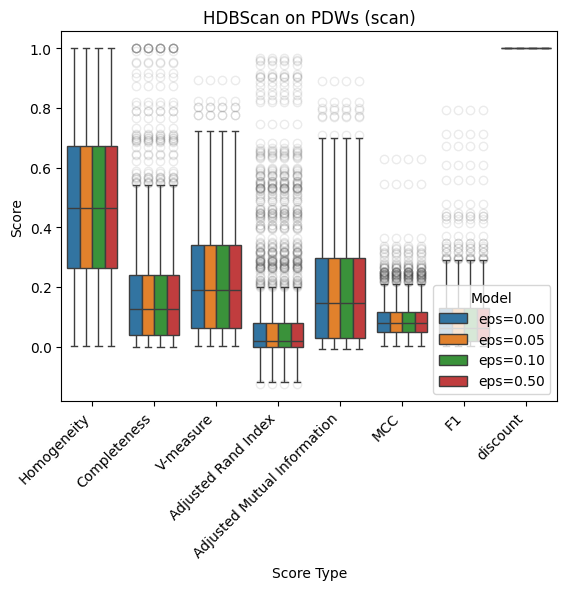

In [35]:
sns.boxplot(
    scan_performance_pd.melt(
        id_vars=["Model"],
        value_vars=scan_performance_pd.columns[1:].tolist(),
        var_name="Score Type",
        value_name="Score"
    ),
    x="Score Type",
    y="Score",
    hue="Model",
    palette="tab10",
    flierprops={"alpha": .1},
)
plt.xticks(rotation=45, ha="right")
plt.title("HDBScan on PDWs (scan)")
plt.show()

In [36]:
scan_median_summary = scan_performance_pd.melt(
        id_vars=["Model"],
        value_vars=scan_performance_pd.columns[1:].tolist(),
        var_name="Score Type",
        value_name="Score"
).groupby(["Model", "Score Type"]).median().sort_index()
scan_median_summary

Score
Model    Score Type                           
eps=0.00 Adjusted Mutual Information  0.145516
         Adjusted Rand Index          0.018280
         Completeness                 0.125443
         F1                           0.061072
         Homogeneity                  0.463883
         MCC                          0.079395
         V-measure                    0.188900
         discount                     1.000000
eps=0.05 Adjusted Mutual Information  0.145516
         Adjusted Rand Index          0.018280
         Completeness                 0.125443
         F1                           0.061072
         Homogeneity                  0.463883
         MCC                          0.079395
         V-measure                    0.188900
         discount                     1.000000
eps=0.10 Adjusted Mutual Information  0.145516
         Adjusted Rand Index          0.018280
         Completeness                 0.125443
         F1                           0.061072
         Homogeneity                  0.463883
         MCC                          0.079395
         V-measure                    0.188900
         discount                     1.000000
eps=0.50 Adjusted Mutual Information  0.145516
         Adjusted Rand Index          0.018280
         Completeness                 0.125443
         F1                           0.061072
         Homogeneity                  0.463883
         MCC                          0.079395
         V-measure                    0.188900
         discount                     1.000000

In [37]:
# Arbitrarily select first model and run entire dataset against it. this might take a while...
tdc_scan_results = tdc.models.evaluate.evaluate_model_on_dataset(
    model=scan_identity_model_list[0],
    dataloader=tdc_scan,
    return_average=False,
    n_jobs=10,
)

Evaluating model: 25494it [01:04, 398.11it/s]
Fetch results: 100%|██████████| 25494/25494 [17:44<00:00, 23.95it/s] 


In [38]:
scan_performance_pd = pd.DataFrame(tdc_scan_results)
scan_performance_pd.head()

,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Information,MCC,F1,discount
0,0.940668,0.043646,0.083420,0.005182,0.068525,0.048977,0.033898,1.0
1,0.664651,0.280988,0.394990,0.087622,0.354377,0.138519,0.142857,1.0
2,0.058310,0.011028,0.018548,0.003662,0.007538,0.076035,0.161039,1.0
3,0.602252,0.704791,0.649499,0.536171,0.646111,0.069907,0.032258,1.0
4,0.681854,0.163621,0.263912,0.022305,0.209131,0.156402,0.129870,1.0


In [39]:
median_scan_summary = scan_performance_pd.melt(
        value_vars=scan_performance_pd.columns.tolist(),
        var_name="Score Type",
        value_name="Score"
).groupby(["Score Type"]).median().sort_index()
median_scan_summary

,Score
Score Type,
Adjusted Mutual Information,0.145545
Adjusted Rand Index,0.016923
Completeness,0.127409
F1,0.037736
Homogeneity,0.409352
MCC,0.071310
V-measure,0.187153
discount,1.000000


In [40]:
scan_performance_pd["Rx Model"] = "scan"
stare_performance_pd["Rx Model"] = "stare"
model_performance = pd.concat([stare_performance_pd, scan_performance_pd])

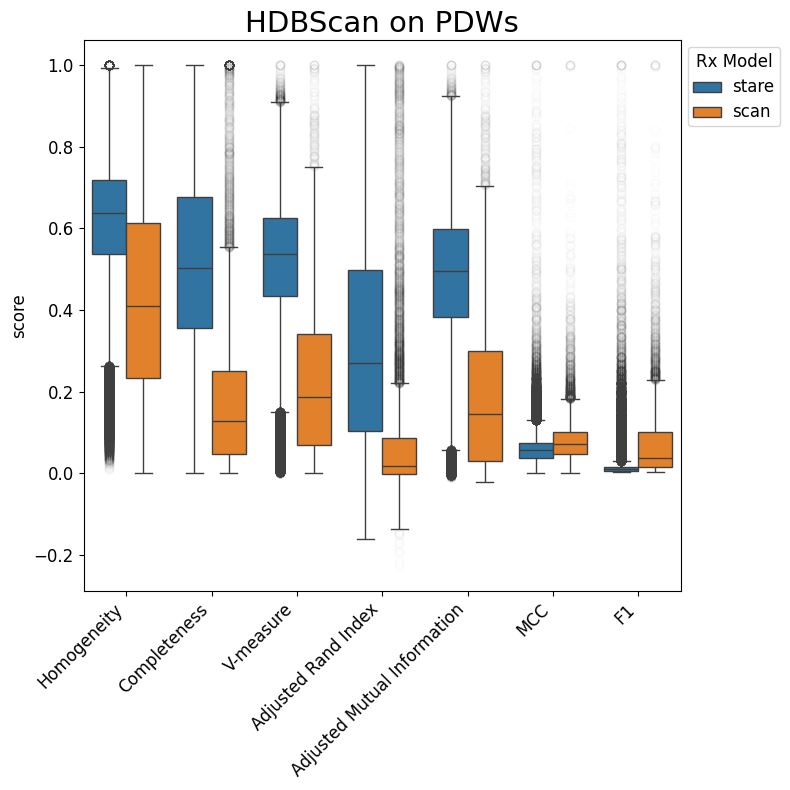

In [63]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax = sns.boxplot(
    model_performance.drop(columns=["discount"]).melt(
        id_vars=["Rx Model"],
        value_vars=model_performance.columns[:-2].tolist(),
        var_name="Score Type",
        value_name="Score"
    ),
    x="Score Type",
    y="Score",
    hue="Rx Model",
    palette="tab10",
    flierprops={"alpha": .01},
    ax=ax
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45, ha="right")
plt.xlabel("")
plt.ylabel("score", fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title("HDBScan on PDWs", fontsize=21)
plt.setp(ax.get_legend().get_texts(), fontsize='12') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='12') # for legend title
fig.tight_layout()
plt.savefig("../figures/hdbscan_deinterleaving_performance_largefont.pdf")


In [55]:
sns.reset_orig()